<a href="https://colab.research.google.com/github/souhaOomrani/Titanic-Machine-Learning/blob/main/Titanic_Project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🛢️ **Loading the Data**

In [28]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
df = pd.read_csv("drive/MyDrive/Titanic.csv")
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


#🧹 **Data Cleaning**

In [30]:
#Checking for missing values
# Check missing values
df.isnull().sum()

# 1. Fill numeric missing values
df["age"] = df["age"].fillna(df["age"].median())

# 2. Drop rows missing fare or embarked
df = df.dropna(subset=["fare", "embarked"])

# 3. Fill categorical columns
df["boat"] = df["boat"].fillna("Unknown")
df["home.dest"] = df["home.dest"].fillna(df["home.dest"].mode()[0])

# 4. Drop useless columns
df = df.drop(columns=["body", "cabin"])

df.isnull().sum()

/tmp/ipykernel_2386/3268345656.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["boat"] = df["boat"].fillna("Unknown")
/tmp/ipykernel_2386/3268345656.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["home.dest"] = df["home.dest"].fillna(df["home.dest"].mode()[0])


,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
embarked,0


#👩‍🔧 **Outlier Detection and Treatment**

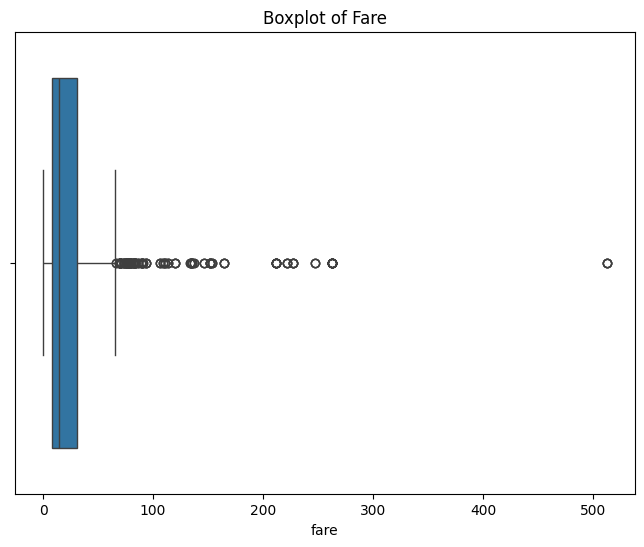

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,home.dest
49,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,3,"Austria-Hungary / Germantown, Philadelphia, PA"
50,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,C,3,"Germantown, Philadelphia, PA"
183,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,3,"New York, NY"
302,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,3,"New York, NY"


In [31]:
#Boxplot for 'fare' to detect outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['fare'])
plt.title('Boxplot of Fare')
plt.show()

#Passengers with very high fares
df[df['fare'] > 500]

#📒 **Categorical Variable Encoding**

In [32]:
#Label Encoding on 'sex': {'male': 0, 'female':1}
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

#One-Hot Encoding on 'embarked'
df = pd.get_dummies(df, columns=['embarked'], prefix=['embarked'])

#Display these columns
df[['sex', 'embarked_C', 'embarked_Q', 'embarked_S']].head()

,sex,embarked_C,embarked_Q,embarked_S
0,0,False,False,True
1,1,False,False,True
2,0,False,False,True
3,1,False,False,True
4,0,False,False,True


#📝 **Feature Engineering**

In [33]:
#New Column 'Family Size'
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['family_size'].value_counts()

#New Binary Variable 'Travelled Alone'
df['travelled_alone'] = np.where(df['family_size'] == 1, 1, 0)
df['travelled_alone'].value_counts()

,count
travelled_alone,
1,787
0,519


#📊 **Visualization**

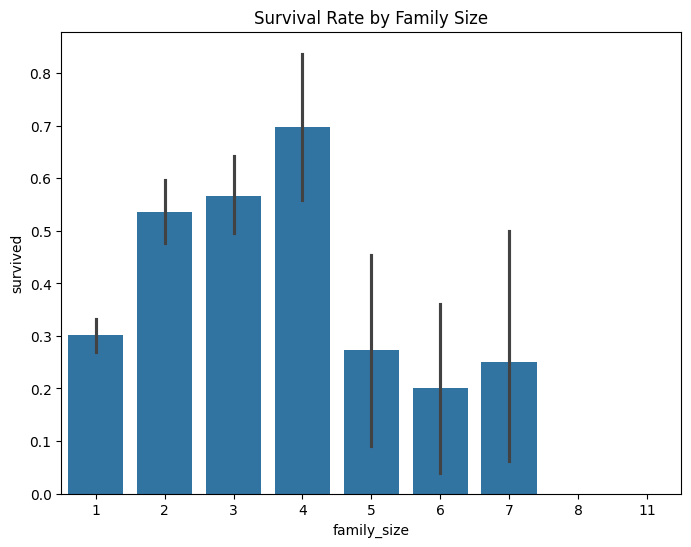

In [34]:
#Display the Survival Rate by Family Size
plt.figure(figsize=(8, 6))
sns.barplot(x='family_size', y='survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

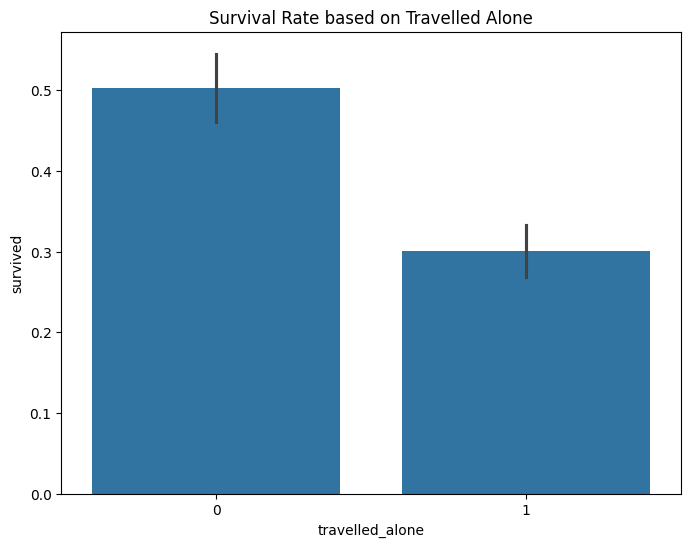

In [35]:
#Display the Survival Rate based on Whether the passenger was alone or not
plt.figure(figsize=(8, 6))
sns.barplot(x='travelled_alone', y='survived', data=df)
plt.title('Survival Rate based on Travelled Alone')
plt.show()

#**😀 Visualize Correlation**

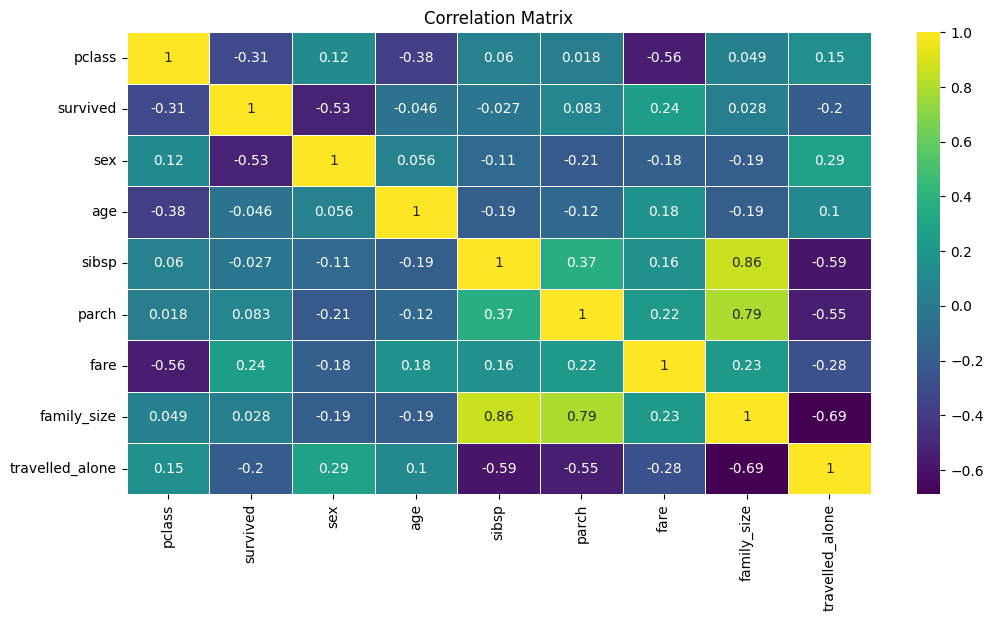

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()

plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="viridis", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

#**⛓️ Split**

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


#**📝 Preprocessing Pipeline**

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols)
])


#**📈PART 1 — Classification (SVC, KNN, Logistic Regression, Random Forest)**

#**📌A. Logistic Regression - GridSearch**

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Pipeline with placeholder replaced by logistic regression
pipe_lr = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

# GridSearch parameters
param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best LR score:", grid_lr.best_score_)


Best Logistic Regression params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR score: 0.9760627530364372


#**📌 B. KNN – GridSearch**

In [40]:
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("prep", preprocess),
    ("model", KNeighborsClassifier())
])

param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]  # Manhattan or Euclidean
}

grid_knn = GridSearchCV(pipe_knn, param_knn, cv=5, scoring="accuracy", n_jobs=-1)
grid_knn.fit(X_train, y_train)

print("Best KNN params:", grid_knn.best_params_)
print("Best KNN score:", grid_knn.best_score_)


Best KNN params: {'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'distance'}
Best KNN score: 0.9310406698564593


#**📌 C. SVC – GridSearch**

In [41]:
from sklearn.svm import SVC

pipe_svc = Pipeline([
    ("prep", preprocess),
    ("model", SVC())
])

param_svc = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["rbf", "linear", "poly"],
    "model__gamma": ["scale", "auto"]
}

grid_svc = GridSearchCV(pipe_svc, param_svc, cv=5, scoring="accuracy", n_jobs=-1)
grid_svc.fit(X_train, y_train)

print("Best SVC params:", grid_svc.best_params_)
print("Best SVC score:", grid_svc.best_score_)

Best SVC params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best SVC score: 0.9760627530364372


#**📌D. Random Forest – GridSearch**

In [42]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier())
])

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best RF score:", grid_rf.best_score_)


Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best RF score: 0.9760627530364372


# **⭐ Best Model for deployment**

In [43]:
results = {
    "Logistic Regression": grid_lr.best_score_,
    "KNN": grid_knn.best_score_,
    "SVC": grid_svc.best_score_,
    "Random Forest": grid_rf.best_score_
}

results

{'Logistic Regression': np.float64(0.9760627530364372),
 'KNN': np.float64(0.9310406698564593),
 'SVC': np.float64(0.9760627530364372),
 'Random Forest': np.float64(0.9760627530364372)}

#**Part 2 : Regression Problem**

#**Define Features and Target**

#🎯 Regression target = fare

In [44]:
y = df["fare"]
X = df.drop(columns=["fare"])

#**Train/Test Split**

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#**Build Preprocessing Pipeline**

In [46]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric, num_cols),
    ("cat", categorical, cat_cols)
])


#**🚀 Regression Models + GridSearch**

#**📌 A. Linear Regression – GridSearchCV**

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])

param_lr = {}  # no parameters to tune

grid_lr = GridSearchCV(pipe_lr, param_lr, cv=5, scoring="neg_mean_squared_error")
grid_lr.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'family_size',
       'travelled_alone'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['name', 'ticket', 'boat', 'home.dest'], dtype='object'))])),
                                       ('model', LinearRegression())]),
             param_grid={}, scoring='neg_mean_squared_error')

#**📌 B. SVR – GridSearchCV**

In [48]:
from sklearn.svm import SVR

pipe_svr = Pipeline([
    ("prep", preprocess),
    ("model", SVR())
])

param_svr = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto"]
}

grid_svr = GridSearchCV(pipe_svr, param_svr, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_svr.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'family_size',
       'travelled_alone'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['name', 'ticket', 'boat', 'home.dest'], dtype='object'))])),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10, 100],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['rbf', 'linear']},
             scoring='neg_mean_squared_error')

#**📌 C. RandomForestRegressor – GridSearchCV**

In [49]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor())
])

param_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(pipe_rf, param_rf, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'family_size',
       'travelled_alone'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['name', 'ticket', 'boat', 'home.dest'], dtype='object'))])),
                                       ('model', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

#**⭐ Compare Models**

In [50]:
results_reg = {
    "Linear Regression": grid_lr.best_score_,
    "SVR": grid_svr.best_score_,
    "Random Forest": grid_rf.best_score_
}

results_reg

{'Linear Regression': np.float64(-393.9712921272211),
 'SVR': np.float64(-439.7878590724936),
 'Random Forest': np.float64(-505.0213121622481)}

In [51]:
best_model = max(results_reg, key=results_reg.get)
best_model

'Linear Regression'